<a href="https://colab.research.google.com/github/MuhammadFarhan96/Progree/blob/main/Progree_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

print("Dataset shape:", df.shape)
print(df.head())
print(df.info())

Dataset shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-nul

In [3]:
# Create a categorical feature from median income

df["IncomeCategory"] = pd.cut(
    df["MedInc"],
    bins=[0, 2, 4, 6, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

# Introduce some missing values for demonstration

np.random.seed(42)

missing_indices = np.random.choice(
    df.index,
    size=100,
    replace=False
)

df.loc[missing_indices, "AveRooms"] = np.nan

print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal IncomeCategory  
0    -122.23        4.526      Very High  
1    -122.22        3.585      Very High  
2    -122.24        3.521      Very High  
3    -122.25        3.413           High  
4    -122.25        3.422         Medium  

Missing values:
MedInc              0
HouseAge            0
AveRooms          100
AveBedrms           0
Population          0
AveOccup            0
Latitude            0
Longitude           0
MedHouseVal         0
IncomeCategory      0
dtype: int64


In [4]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 9)
Target shape: (20640,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 9)
Testing data: (4128, 9)


In [6]:
numeric_features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude"
]

categorical_features = [
    "IncomeCategory"
]

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numeric columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Categorical columns: ['IncomeCategory']


In [7]:
# Numeric pipeline:
# 1. Fill missing values using mean
# 2. Scale features

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

# Categorical pipeline:
# 1. Fill missing values using most frequent category
# 2. Convert categories into numbers

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both pipelines

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created!")

Preprocessing pipeline created!


In [8]:
model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

print(model)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MedInc', 'HouseAge',
                                                   'AveRooms', 'AveBedrms',
                                                   'Population', 'AveOccup',
                                                   'Latitude', 'Longitude']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                     

In [9]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [10]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test.iloc[:10].values)

First 10 predictions:
[0.56269819 1.72774177 2.46437342 2.81532501 2.50297624 1.97059142
 2.70124571 2.01344997 2.52029654 4.23095732]

First 10 actual values:
[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]


In [11]:
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("RMSE:", rmse)

R² Score: 0.575510382108938
RMSE: 0.7458250508359828


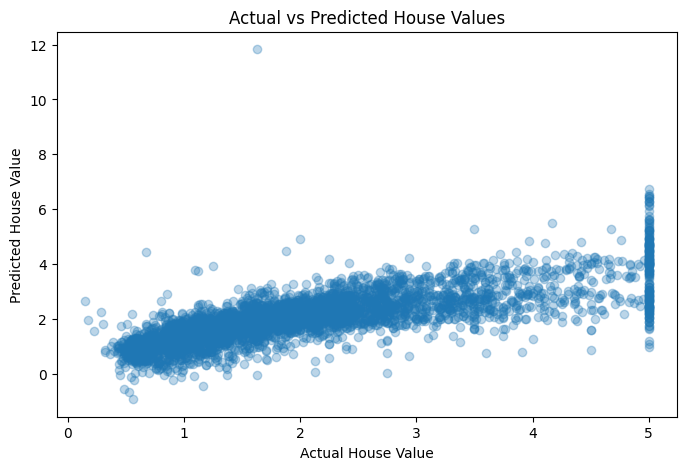

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

In [13]:
import joblib

joblib.dump(model, "california_ridge_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!
